# Optimization Landscapes

**Goal.** Distinguish convex minima, ill-conditioning, and saddle points through Hessian eigenvalues.
Visualize how gradient descent behaves on each landscape.


In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)


## Classifying stationary points via Hessian eigenvalues

At a stationary point ($\nabla f = 0$), the Hessian determines the nature:

| Eigenvalues | Hessian type | Point type | Shape |
|---|---|---|---|
| All $> 0$ | Positive definite | **Minimum** | Bowl |
| All $< 0$ | Negative definite | **Maximum** | Inverted bowl |
| Mixed signs | Indefinite | **Saddle point** | Saddle |
| Has $= 0$ | Semidefinite | Inconclusive | Flat direction |


## 3D surfaces: bowl vs saddle vs maximum

Three quadratic functions, each with a different Hessian type.


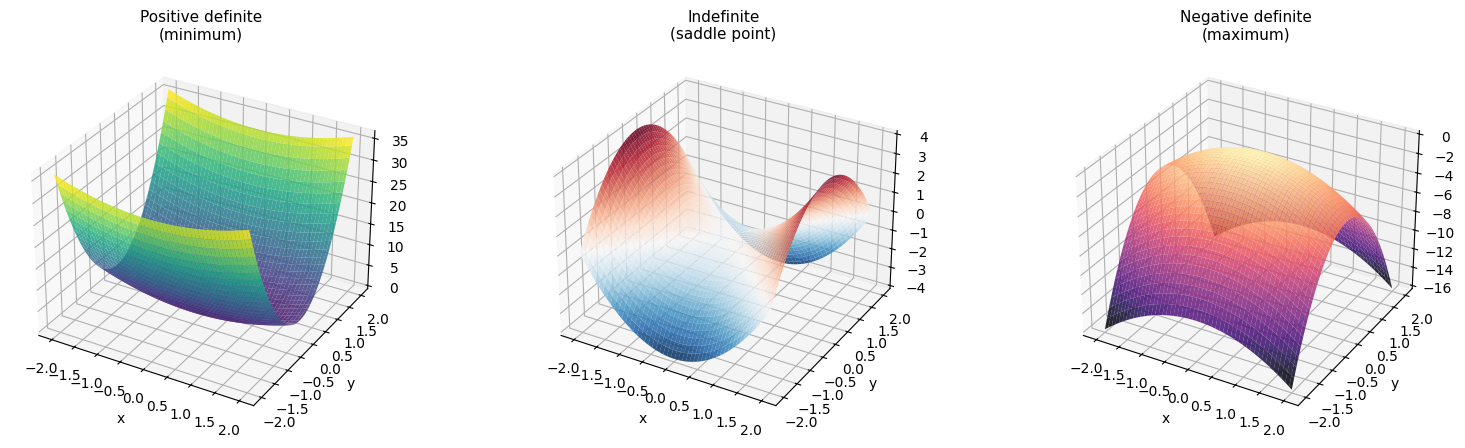

In [2]:
grid = np.linspace(-2.0, 2.0, 150)
X, Y = np.meshgrid(grid, grid)

# Three landscape types
Z_convex = X**2 + 8 * Y**2          # H = diag(2, 16), both positive
Z_saddle = X**2 - Y**2              # H = diag(2, -2), mixed
Z_concave = -(X**2 + 3 * Y**2)      # H = diag(-2, -6), both negative

fig = plt.figure(figsize=(16, 4.5))
surfaces = [
    (Z_convex, "Positive definite\n(minimum)", "viridis"),
    (Z_saddle, "Indefinite\n(saddle point)", "RdBu_r"),
    (Z_concave, "Negative definite\n(maximum)", "magma"),
]

for i, (Z, title, cmap) in enumerate(surfaces):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.plot_surface(X, Y, Z, cmap=cmap, alpha=0.85, edgecolor="none")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.show()


## Contour plots + eigenvalue verification

Contour shapes reveal curvature:
- **Circles** -> equal eigenvalues (kappa = 1)
- **Ellipses** -> unequal eigenvalues (kappa > 1, ill-conditioned)
- **Hyperbolas** -> mixed-sign eigenvalues (saddle)


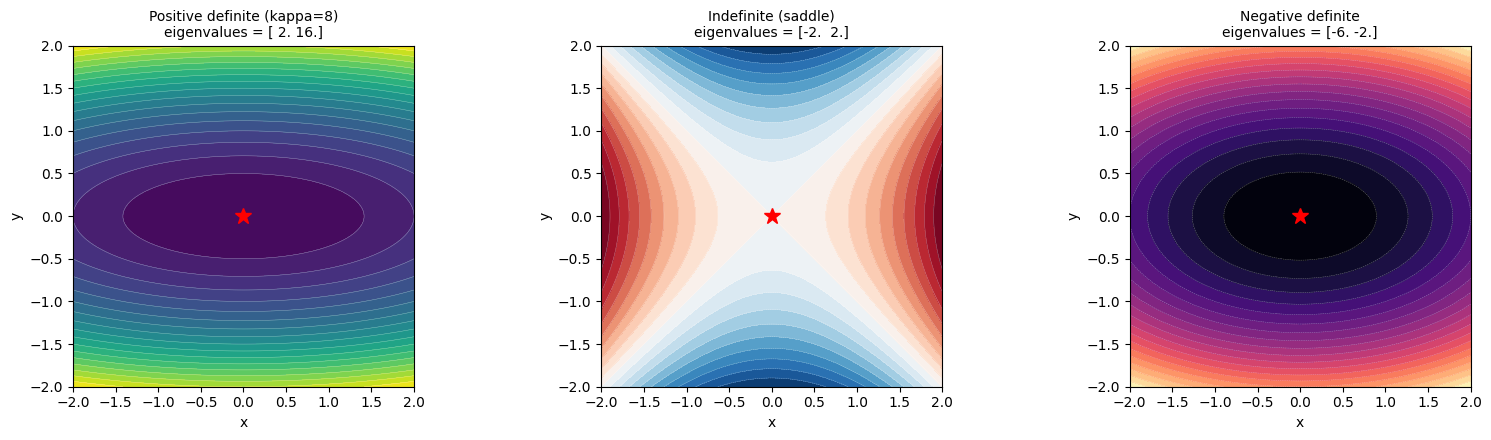

All eigenvalue assertions passed.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

data = [
    (Z_convex, "Positive definite (kappa=8)", "viridis", np.diag([2.0, 16.0])),
    (Z_saddle, "Indefinite (saddle)", "RdBu_r", np.diag([2.0, -2.0])),
    (Z_concave, "Negative definite", "magma_r", np.diag([-2.0, -6.0])),
]

for ax, (Z, title, cmap, H) in zip(axes, data):
    ax.contourf(X, Y, Z, levels=20, cmap=cmap)
    ax.contour(X, Y, Z, levels=20, colors="white", linewidths=0.3, alpha=0.5)
    ax.plot(0, 0, "r*", ms=12, zorder=5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    eigs = np.linalg.eigvalsh(H)
    ax.set_title(f"{title}\neigenvalues = {eigs}", fontsize=10)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Assertions
assert np.all(np.linalg.eigvalsh(np.diag([2.0, 16.0])) > 0.0), "Convex should have all positive eigenvalues"
assert np.any(np.linalg.eigvalsh(np.diag([2.0, -2.0])) < 0.0), "Saddle should have a negative eigenvalue"
assert np.all(np.linalg.eigvalsh(np.diag([-2.0, -6.0])) < 0.0), "Concave should have all negative eigenvalues"
print("All eigenvalue assertions passed.")


## Gradient descent on an ill-conditioned bowl

For $f(x,y) = x^2 + 8y^2$, the condition number is $\kappa = 16/2 = 8$.
GD must use a small learning rate (limited by $\lambda_{\max} = 16$),
which is too small for the $\lambda_{\min} = 2$ direction -> **zigzag**.


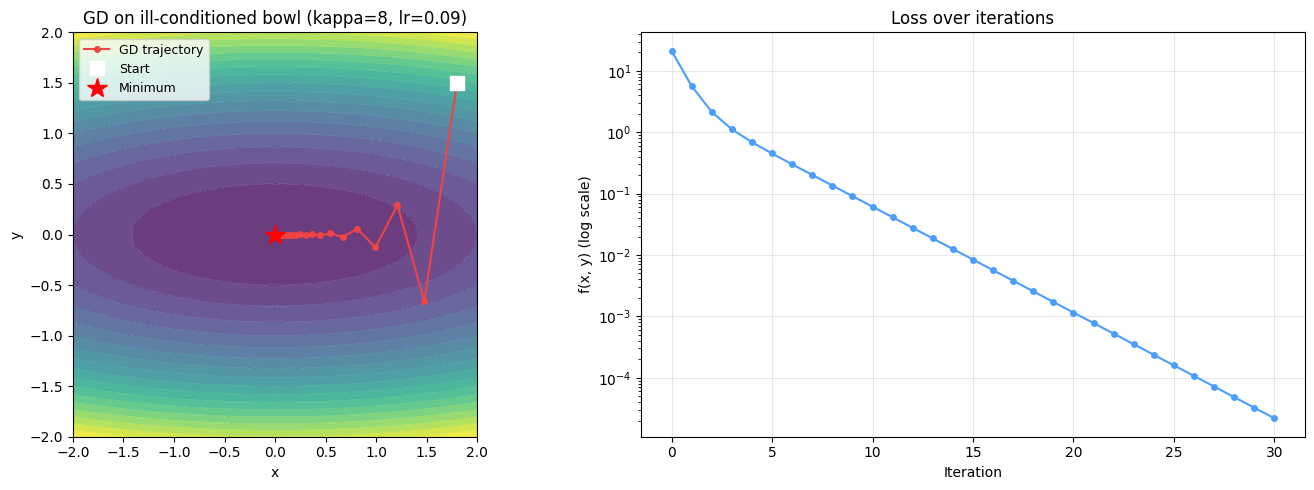

Start: f(1.8, 1.5) = 21.24
After 30 steps: f(0.0047, 0.0000) = 0.000022
Note the zigzag pattern: GD oscillates across the narrow valley (y-axis)
while making slow progress along the wide valley (x-axis).


In [4]:
def gradient_descent_2d(grad_fn, x0, lr, n_steps):
    """Run GD and return trajectory."""
    path = [np.array(x0, dtype=float)]
    x = path[0].copy()
    for _ in range(n_steps):
        x = x - lr * grad_fn(x)
        path.append(x.copy())
    return np.array(path)

# f(x,y) = x^2 + 8y^2, grad = [2x, 16y]
grad_convex = lambda p: np.array([2 * p[0], 16 * p[1]])

x0 = [1.8, 1.5]
lr = 0.09  # close to 2/16 = 0.125 stability limit
path = gradient_descent_2d(grad_convex, x0, lr, n_steps=30)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: trajectory on contour
ax = axes[0]
ax.contourf(X, Y, Z_convex, levels=20, cmap="viridis", alpha=0.8)
ax.contour(X, Y, Z_convex, levels=20, colors="white", linewidths=0.3, alpha=0.5)
ax.plot(path[:, 0], path[:, 1], "o-", color="#ef4444", ms=4, lw=1.5, label="GD trajectory")
ax.plot(*x0, "ws", ms=10, zorder=5, label="Start")
ax.plot(0, 0, "r*", ms=15, zorder=5, label="Minimum")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"GD on ill-conditioned bowl (kappa=8, lr={lr})")
ax.legend(fontsize=9)
ax.set_aspect("equal")

# Right: loss over iterations
ax = axes[1]
losses = path[:, 0]**2 + 8 * path[:, 1]**2
ax.semilogy(losses, "o-", color="#4a9eff", ms=4)
ax.set_xlabel("Iteration")
ax.set_ylabel("f(x, y) (log scale)")
ax.set_title("Loss over iterations")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Start: f{tuple(x0)} = {x0[0]**2 + 8*x0[1]**2:.2f}")
print(f"After 30 steps: f({path[-1][0]:.4f}, {path[-1][1]:.4f}) = {losses[-1]:.6f}")
print(f"Note the zigzag pattern: GD oscillates across the narrow valley (y-axis)")
print(f"while making slow progress along the wide valley (x-axis).")


## Gradient descent near a saddle point

For $f(x,y) = x^2 - y^2$, the origin is a saddle point.
If GD starts exactly on the $x$-axis (the ascending direction), it converges to the saddle.
A tiny perturbation in $y$ causes it to escape along the descent direction.


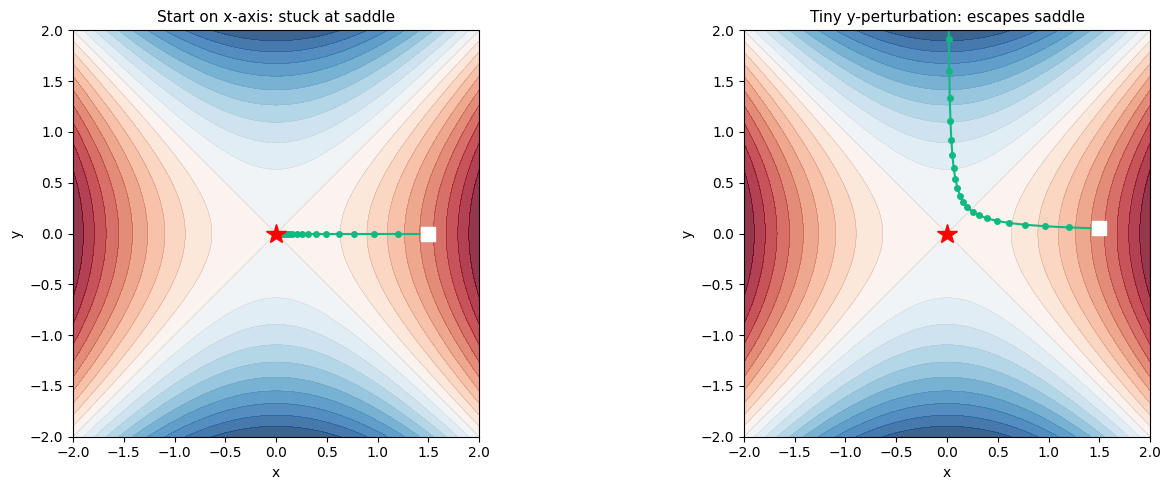

Path 1 (no perturbation): ends at (0.000199, 0.000000)
  -> Converges to saddle point along x-axis
Path 2 (y += 0.05): ends at (0.000199, 73.488578)
  -> Escapes saddle along the negative-curvature direction (y-axis)
  -> This is why SGD noise helps escape saddle points in deep learning.


In [5]:
grad_saddle = lambda p: np.array([2 * p[0], -2 * p[1]])

# Path 1: start on x-axis -> converges TO saddle (no escape)
path_stuck = gradient_descent_2d(grad_saddle, [1.5, 0.0], lr=0.1, n_steps=40)

# Path 2: tiny y perturbation -> escapes along y-axis
path_escape = gradient_descent_2d(grad_saddle, [1.5, 0.05], lr=0.1, n_steps=40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path_data, title, start in zip(
    axes,
    [path_stuck, path_escape],
    ["Start on x-axis: stuck at saddle", "Tiny y-perturbation: escapes saddle"],
    [[1.5, 0.0], [1.5, 0.05]],
):
    ax.contourf(X, Y, Z_saddle, levels=20, cmap="RdBu_r", alpha=0.8)
    ax.contour(X, Y, Z_saddle, levels=20, colors="black", linewidths=0.2, alpha=0.3)
    ax.plot(path_data[:, 0], path_data[:, 1], "o-", color="#10b981", ms=4, lw=1.5)
    ax.plot(*start, "ws", ms=10, zorder=5)
    ax.plot(0, 0, "r*", ms=15, zorder=5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

print(f"Path 1 (no perturbation): ends at ({path_stuck[-1][0]:.6f}, {path_stuck[-1][1]:.6f})")
print(f"  -> Converges to saddle point along x-axis")
print(f"Path 2 (y += 0.05): ends at ({path_escape[-1][0]:.6f}, {path_escape[-1][1]:.6f})")
print(f"  -> Escapes saddle along the negative-curvature direction (y-axis)")
print(f"  -> This is why SGD noise helps escape saddle points in deep learning.")


## Result

1. A zero gradient is **not sufficient** for a minimum. Hessian eigenvalues classify the point.
2. Ill-conditioned bowls (kappa >> 1) cause GD to **zigzag** -- motivates momentum and adaptive methods.
3. Saddle points are **unstable equilibria** for GD -- any perturbation (e.g., SGD noise) causes escape along negative-curvature directions.
4. In high dimensions, saddle points are far more common than local minima -- this is why SGD still works for neural networks despite non-convexity.
